In [2]:
!pip install fastembed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 27.9 MB/s eta 0:00:00


In [1]:
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_json("hf://datasets/Amod/mental_health_counseling_conversations/combined_dataset.json", lines=True)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Context   3512 non-null   object
 1   Response  3512 non-null   object
dtypes: object(2)
memory usage: 55.0+ KB


Text(0, 0.5, 'Freq')

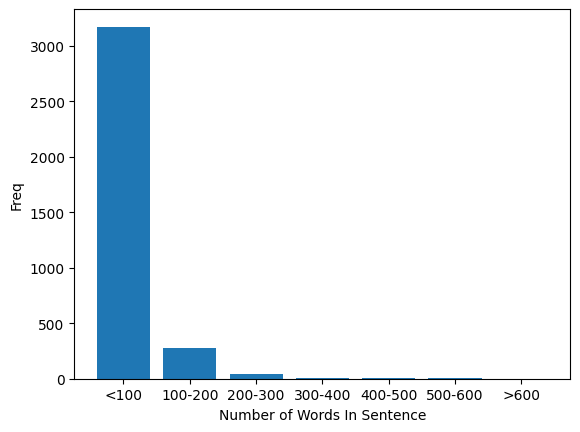

In [4]:
import matplotlib.pyplot as plt
Lengths = {"<100":0,"100-200":0,"200-300":0,"300-400":0,"400-500":0,"500-600":0,">600":0}
for txt in df['Context'].values:
  size = len(str(txt).split(' '))

  if size < 100:
      Lengths["<100"] += 1
  elif size <= 200:
      Lengths["100-200"] += 1
  elif size <= 300:
      Lengths["200-300"] += 1
  elif size <= 400:
      Lengths["300-400"] += 1
  elif size <= 500:
      Lengths["400-500"] += 1
  elif size <= 600:
      Lengths["500-600"] += 1
  else:
      Lengths[">600"] += 1

plt.bar(Lengths.keys(),Lengths.values())
plt.xlabel("Number of Words In Sentence")
plt.ylabel("Freq")

In [3]:
from sentence_transformers import SentenceTransformer
from fastembed import SparseTextEmbedding

dense_model = SentenceTransformer("all-MiniLM-L6-v2")
sparse_model = SparseTextEmbedding("Qdrant/bm25")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

In [4]:
!pip install qdrant-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 8.2 MB/s eta 0:00:00


In [ ]:
from qdrant_client import QdrantClient


client = QdrantClient(
    url=url,
    api_key=url)

In [ ]:
client.create_collection(
    collection_name="VectorDatabase",
    vectors_config={
        "dense": VectorParams(size=DENSE_DIM, distance=Distance.COSINE)
    },
    sparse_vectors_config={
        "sparse": SparseVectorParams(index=SparseIndexParams(on_disk=False))
    },
)


In [23]:
contexts  = df["Context"].tolist()
responses = df["Response"].tolist()
total     = len(df)

In [25]:
from qdrant_client.models import PointStruct, SparseVector

uploaded = 0

for start in range(0, total, 32):
    end = min(start + 32, total)

    batch_contexts  = contexts[start:end]
    batch_responses = responses[start:end]
    batch_ids       = list(range(start, end))

    batch_dense = dense_model.encode(batch_contexts, show_progress_bar=False).tolist()
    batch_sparse = list(sparse_model.embed(batch_contexts))

    points = []
    for i in range(len(batch_contexts)):
        points.append(
            PointStruct(
                id=batch_ids[i],
                vector={
                    "dense": batch_dense[i],
                    "sparse": SparseVector(
                        indices=batch_sparse[i].indices.tolist(),
                        values=batch_sparse[i].values.tolist(),
                    ),
                },
                payload={
                    "Context":  batch_contexts[i],
                    "Response": batch_responses[i],
                },
            )
        )

    client.upsert(collection_name="VectorDatabase", points=points)
    uploaded += len(points)
    print(f"  Uploaded {uploaded}/{total} points")

print("Dataset uploaded successfully")

  Uploaded 32/3512 points
  Uploaded 64/3512 points
  Uploaded 96/3512 points
  Uploaded 128/3512 points
  Uploaded 160/3512 points
  Uploaded 192/3512 points
  Uploaded 224/3512 points
  Uploaded 256/3512 points
  Uploaded 288/3512 points
  Uploaded 320/3512 points
  Uploaded 352/3512 points
  Uploaded 384/3512 points
  Uploaded 416/3512 points
  Uploaded 448/3512 points
  Uploaded 480/3512 points
  Uploaded 512/3512 points
  Uploaded 544/3512 points
  Uploaded 576/3512 points
  Uploaded 608/3512 points
  Uploaded 640/3512 points
  Uploaded 672/3512 points
  Uploaded 704/3512 points
  Uploaded 736/3512 points
  Uploaded 768/3512 points
  Uploaded 800/3512 points
  Uploaded 832/3512 points
  Uploaded 864/3512 points
  Uploaded 896/3512 points
  Uploaded 928/3512 points
  Uploaded 960/3512 points
  Uploaded 992/3512 points
  Uploaded 1024/3512 points
  Uploaded 1056/3512 points
  Uploaded 1088/3512 points
  Uploaded 1120/3512 points
  Uploaded 1152/3512 points
  Uploaded 1184/3512 point

In [37]:
info = client.get_collection("VectorDatabase")
print(info.points_count)

3512
